# Load reviews dataset

# Reviews Feature Engineering

This notebook analyzes Airbnb review data and creates review-based features at the listing level.

The objective is to transform individual guest reviews into aggregated variables that can later be used for price prediction and listing analysis.

Main features created:
- review_count: total number of reviews per listing
- avg_review_length: average review length per listing
- latest_review_date: most recent review date per listing

In [68]:
#setup
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)

Project root: /Users/antoniacordova/Data for business/airbnb-rome-analysis


In [69]:
reviews = pd.read_csv(
    "../data/reviews.csv.gz",
    compression="gzip"
)

In [70]:
reviews.info()
reviews.head()

<class 'pandas.DataFrame'>
RangeIndex: 2193330 entries, 0 to 2193329
Data columns (total 6 columns):
 #   Column         Dtype
---  ------         -----
 0   listing_id     int64
 1   id             int64
 2   date           str  
 3   reviewer_id    int64
 4   reviewer_name  str  
 5   comments       str  
dtypes: int64(3), str(3)
memory usage: 100.4 MB


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,2737,24343517,2014-12-26,24333039,Raphaell,"This spot was in a great and nice area,walking..."
1,2737,24966779,2015-01-04,10493776,Ia,"Elif was really very helpful, while arranging ..."
2,2737,29770086,2015-04-12,29630601,Julia,"Elif's flat is spacious, clean, and had everyt..."
3,2737,30477570,2015-04-22,31215535,Sevil,I had a wonderful time staying with Elif and h...
4,2737,31659336,2015-05-08,1959813,Suzy,"Elif was a brilliant host, with an exceptional..."


## Review Length Feature

Review length is measured as the number of words contained in each review comment.

This variable is used as a proxy for guest engagement and review detail.

In [71]:
reviews["comments"] = reviews["comments"].fillna("")
reviews["review_length"] = reviews["comments"].str.split().str.len()

## Aggregate Reviews at Listing Level

Individual reviews are aggregated into listing-level features.

For each listing we calculate:
- Total number of reviews
- Average review length

In [72]:
review_features = (
    reviews
    .groupby("listing_id")
    .agg(
        review_count=("comments", "count"),
        avg_review_length=("review_length", "mean")
    )
    .reset_index()
)

review_features.head()

,listing_id,review_count,avg_review_length
0,2737,5,51.800000
1,11834,284,76.450704
2,12398,85,84.658824
3,19965,178,44.410112
4,19967,46,33.673913


The resulting dataset contains one observation per listing and summarizes review activity across all reviews associated with that listing.

In [73]:
reviews.columns.tolist()

['listing_id',
 'id',
 'date',
 'reviewer_id',
 'reviewer_name',
 'comments',
 'review_length']

In [74]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 2193330 entries, 0 to 2193329
Data columns (total 7 columns):
 #   Column         Dtype
---  ------         -----
 0   listing_id     int64
 1   id             int64
 2   date           str  
 3   reviewer_id    int64
 4   reviewer_name  str  
 5   comments       str  
 6   review_length  int64
dtypes: int64(4), str(3)
memory usage: 117.1 MB


## Descriptive Statistics

Summary statistics are generated to understand the distribution of the engineered review features.

In [75]:
review_features["review_count"].describe()

count    32255.000000
mean        67.999690
std        103.365598
min          1.000000
25%          7.000000
50%         27.000000
75%         84.000000
max       2819.000000
Name: review_count, dtype: float64

In [76]:
review_features["avg_review_length"].describe()

count    32255.000000
mean        43.809485
std         18.460412
min          0.000000
25%         33.703704
50%         42.386364
75%         51.600000
max        300.000000
Name: avg_review_length, dtype: float64

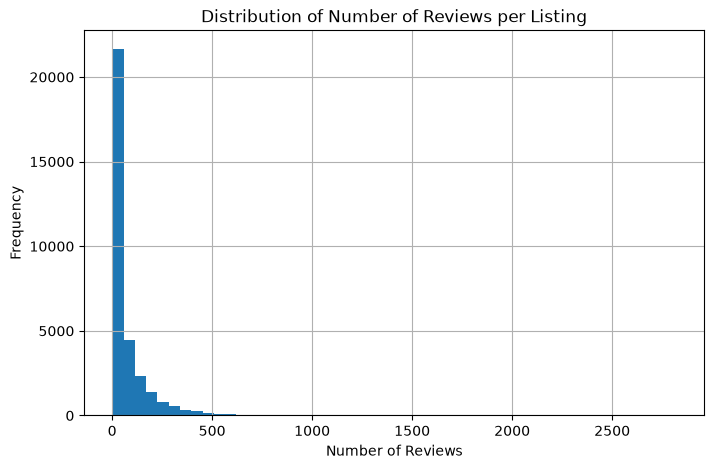

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
review_features["review_count"].hist(bins=50)
plt.title("Distribution of Number of Reviews per Listing")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.show()

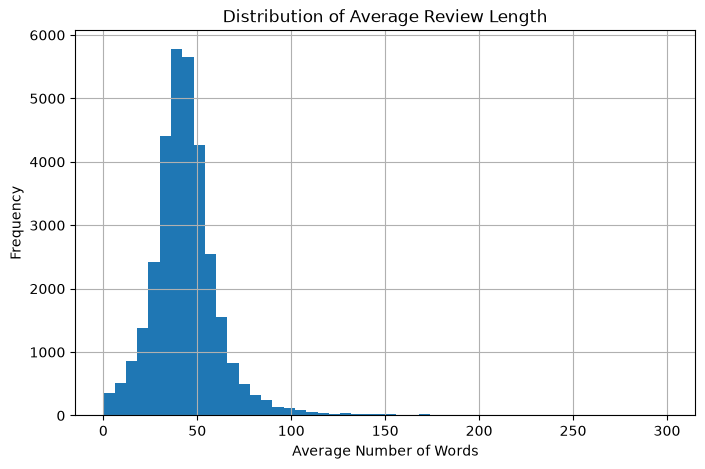

In [78]:
plt.figure(figsize=(8,5))
review_features["avg_review_length"].hist(bins=50)
plt.title("Distribution of Average Review Length")
plt.xlabel("Average Number of Words")
plt.ylabel("Frequency")
plt.show()

Review-based features were engineered by aggregating individual reviews at the listing level. For each listing, the total number of reviews (review_count) and the average review length (avg_review_length) were calculated. Review length was measured as the number of words contained in each review comment.

In [79]:
latest_review = (
    reviews.groupby("listing_id")["date"]
    .max()
    .reset_index(name="latest_review_date")
)

latest_review.head()

,listing_id,latest_review_date
0,2737,2015-05-08
1,11834,2025-07-05
2,12398,2025-08-01
3,19965,2025-08-05
4,19967,2024-07-19


## Latest Review Date

The most recent review date is extracted for each listing.

This feature may provide information about listing activity and recency of guest interactions.

In [80]:
reviews["date"] = pd.to_datetime(reviews["date"])

In [81]:
latest_review = (
    reviews.groupby("listing_id")["date"]
    .max()
    .reset_index(name="latest_review_date")
)

In [82]:
latest_review.head()

,listing_id,latest_review_date
0,2737,2015-05-08
1,11834,2025-07-05
2,12398,2025-08-01
3,19965,2025-08-05
4,19967,2024-07-19


In [83]:
latest_review.head()

,listing_id,latest_review_date
0,2737,2015-05-08
1,11834,2025-07-05
2,12398,2025-08-01
3,19965,2025-08-05
4,19967,2024-07-19


## Save Engineered Features

The aggregated review features are saved for later use in the modeling stage.

In [84]:
review_features.to_csv(
    "../data/review_features.csv",
    index=False
)

print("Review features saved")

Review features saved
